In [131]:
import pandas as pd
import numpy as np
import openmeteo_requests
import requests_cache
from retry_requests import retry

In [143]:
df = pd.read_csv("data/dutch-energy-supplier-load-forecasting-challenge/train_expanded.csv", parse_dates=["timestamp_utc"])
df["timestamp_utc"] = df["timestamp_utc"].dt.tz_localize("UTC")  
df = df.set_index("timestamp_utc")
df.info()

<class 'pandas.core.frame.DataFrame'>
DatetimeIndex: 11048 entries, 2025-05-08 22:00:00+00:00 to 2025-08-31 23:45:00+00:00
Data columns (total 1 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   net_load_kwh  11048 non-null  float64
dtypes: float64(1)
memory usage: 172.6 KB


In [34]:
(df["net_load_kwh"]>0).value_counts().to_frame().T.rename({False: "negative", True:"positive"}, axis=1)

net_load_kwh,negative,positive
count,8500,2548


<Axes: xlabel='timestamp_utc'>

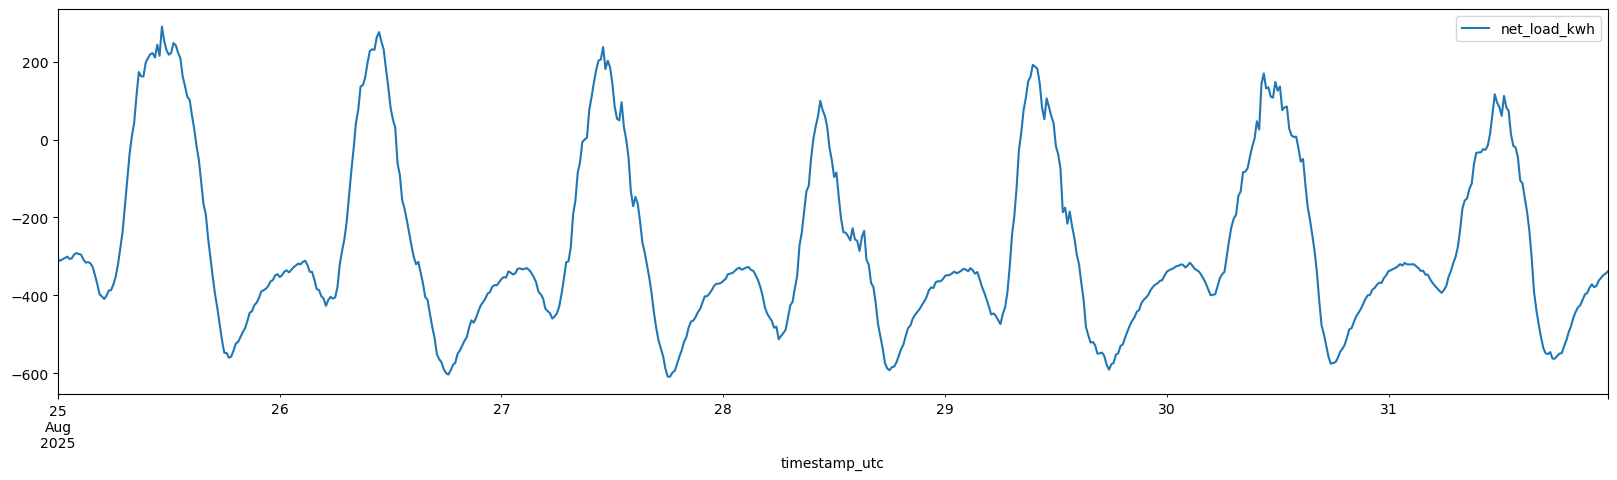

In [53]:
import matplotlib.pyplot as plt
fig, ax = plt.subplots(figsize=(20,5))

df.loc["2025-08-25":].plot(ax=ax)

In [37]:
df.index.min(), df.index.max()

(Timestamp('2025-05-08 22:00:00'), Timestamp('2025-08-31 23:45:00'))

# Add temperature

In [36]:
locations = {
    "Amsterdam": (52.3676, 4.9041),
    "Rotterdam": (51.9244, 4.4777),
    "Utrecht": (52.0907, 5.1214),
    "Eindhoven": (51.4416, 5.4697),
    "Groningen": (53.2194, 6.5665),
}

In [ ]:


# Setup the Open-Meteo API client with cache and retry on error
cache_session = requests_cache.CachedSession('.cache', expire_after = -1)
retry_session = retry(cache_session, retries = 5, backoff_factor = 0.2)
openmeteo = openmeteo_requests.Client(session = retry_session)

# Make sure all required weather variables are listed here
# The order of variables in hourly or daily is important to assign them correctly below
url = "https://archive-api.open-meteo.com/v1/archive"
params = {
	"latitude": locations["Amsterdam"][0],
	"longitude": locations["Amsterdam"][1],
	"start_date": "2025-05-08",
	"end_date": "2025-09-02",
	"hourly": "temperature_2m",
}
responses = openmeteo.weather_api(url, params=params)

# Process first location. Add a for-loop for multiple locations or weather models
response = responses[0]
print(f"Coordinates: {response.Latitude()}°N {response.Longitude()}°E")
print(f"Elevation: {response.Elevation()} m asl")
print(f"Timezone difference to GMT+0: {response.UtcOffsetSeconds()}s")

# Process hourly data. The order of variables needs to be the same as requested.
hourly = response.Hourly()
hourly_temperature_2m = hourly.Variables(0).ValuesAsNumpy()

hourly_data = {"date": pd.date_range(
	start = pd.to_datetime(hourly.Time(), unit = "s", utc = True),
	end = pd.to_datetime(hourly.TimeEnd(), unit = "s", utc = True),
	freq = pd.Timedelta(seconds = hourly.Interval()),
	inclusive = "left"
)}

hourly_data["temperature_2m"] = hourly_temperature_2m

hourly_temp = pd.DataFrame(data = hourly_data)


In [141]:
hourly_temp = pd.read_csv("data/dutch-energy-supplier-load-forecasting-challenge/hourly_weather_data.csv", index_col=0)
hourly_temp["date"] = pd.to_datetime(hourly_temp["date"])
# hourly_temp["date"] = hourly_temp["date"].dt.tz_localize("UTC")  
hourly_temp = hourly_temp.set_index("date")

In [140]:
hourly_temp.dtypes

date              datetime64[ns, UTC]
temperature_2m                float64
dtype: object

In [ ]:
df = df.join( hourly_temp)
df["temperature_2m"] = df["temperature_2m"].interpolate()
df.head(2)

,net_load_kwh,temperature_2m
timestamp_utc,,
2025-05-08 22:00:00+00:00,-317.513,11.4545
2025-05-08 22:15:00+00:00,-308.916,11.2170


# Add seasonal columns and features

In [149]:
df = df.reset_index()
df["hour"] = df["timestamp_utc"].dt.hour
df["day_of_week"] = df["timestamp_utc"].dt.dayofweek
df["month"] = df["timestamp_utc"].dt.month
df["day_of_year"] = df["timestamp_utc"].dt.dayofyear
df["is_weekend"] = df["day_of_week"].isin([5, 6]).astype(int)
df["hdd"] = df["temperature_2m"].apply(lambda x: max(0, 18 - x))
df["cdd"] = df["temperature_2m"].apply(lambda x: max(0, x - 18))

In [147]:
df["hour"] = df["timestamp_utc"].dt.hour + df["timestamp_utc"].dt.minute/60.0
df["hour_sin"]= np.sin(2*np.pi*df["hour"]/24)
df["hour_cos"] = np.cos(2*np.pi*df["hour"]/24)
df["sin_dow"] = np.sin(2*np.pi*df["day_of_week"]/7)
df["cos_dow"] = np.cos(2*np.pi*df["day_of_week"]/7)

# lag features

In [170]:
for i in [4,8,12,24]:
    df[f"ma{i}"] = df["net_load_kwh"].rolling(window=i, min_periods=1).mean()

In [164]:
df.set_index("timestamp_utc", inplace=True)


In [ ]:
for i in range(3,6):
    df[f"load_lag({i})"] = df["net_load_kwh"].shift(i)
for i in range(23,26):
    df[f"load_lag({i})"] = df["ma4"].shift(i)

In [ ]:
df.head(2)

,index,net_load_kwh,temperature_2m,hour,day_of_week,month,day_of_year,is_weekend,hour_sin,hour_cos,...,load_lag(3),load_lag(4),load_lag(5),ma4,load_lag(23),load_lag(24),load_lag(25),ma8,ma12,ma24
timestamp_utc,,,,,,,,,,,,,,,,,,,,,
2025-05-08 22:00:00+00:00,0,-317.513,11.4545,22,3,5,128,0,-0.500000,0.866025,...,NaN,NaN,NaN,-317.5130,NaN,NaN,NaN,-317.5130,-317.5130,-317.5130
2025-05-08 22:15:00+00:00,1,-308.916,11.2170,22,3,5,128,0,-0.442289,0.896873,...,NaN,NaN,NaN,-313.2145,NaN,NaN,NaN,-313.2145,-313.2145,-313.2145


In [ ]:
tr_len = int(len(df)*0.8)
df_train = df.iloc[:tr_len]
df_test = df.iloc[tr_len:]

In [194]:
features= ['temperature_2m', 'month', 'day_of_year', 'is_weekend', 'hour_sin', 'hour_cos', 'sin_dow',
       'cos_dow', 'hdd', 'cdd', #'load_lag(3)', 'load_lag(4)', 'load_lag(5)',
        'load_lag(23)', 'load_lag(24)', 'load_lag(25)']
target = "net_load_kwh"

# Fit model

In [ ]:
from xgboost import XGBRegressor
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
X = df[features]
y = df[target]
X_test = df_test[features]

model = XGBRegressor(n_estimators=100, random_state=42)
model.fit(X,y)


,objective,'reg:squarederror'
,base_score,None
,booster,None
,callbacks,None
,colsample_bylevel,None
,colsample_bynode,None
,colsample_bytree,None
,device,None
,early_stopping_rounds,None
,enable_categorical,False
,eval_metric,None


In [200]:
yhat = model.predict(X)
mean_squared_error(y, yhat), r2_score(y, yhat)

(307.0633655095292, 0.9941853925519241)

In [201]:
ytest_hat = model.predict(df_test[features])
r2_score(df_test[target], ytest_hat)

0.9966382177626693

In [202]:
df_test["pred"] = ytest_hat

C:\Users\mamma\AppData\Local\Temp\ipykernel_35092\3562275231.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_test["pred"] = ytest_hat


In [203]:
pd.Series(model.get_booster().get_score(importance_type='weight')).sort_values()

hdd                 74.0
is_weekend          75.0
month              124.0
cos_dow            171.0
cdd                197.0
sin_dow            256.0
load_lag(24)       267.0
load_lag(25)       353.0
load_lag(23)       500.0
hour_cos           628.0
hour_sin           730.0
temperature_2m     956.0
day_of_year       1176.0
dtype: float64

<Axes: xlabel='timestamp_utc'>

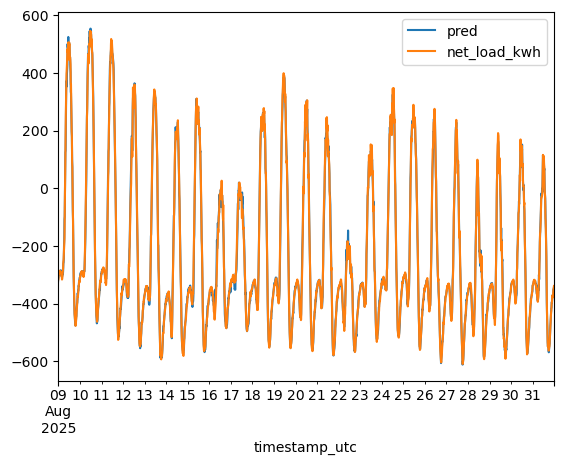

In [205]:
df_test[["pred", target]].plot()

In [206]:
import shap

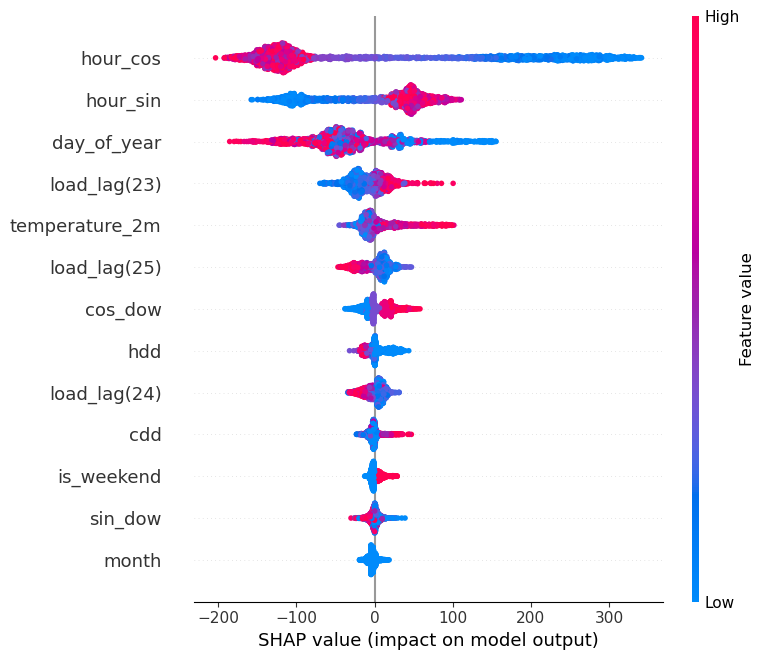

In [ ]:
# Explain with SHAP
explainer1 = shap.Explainer(model, X)
shap_values1 = explainer1(X_test)
shap.summary_plot(shap_values, X_test)

In [219]:
importance = np.mean(np.abs(shap_values), axis=0)
importance

array([ 17.04120476,   4.36650271,  55.01450707,   4.43037807,
        59.34127442, 149.52418807,   4.37841843,  13.36729488,
        10.78692159,   5.0393167 ,  18.110182  ,   9.24453639,
        14.24423272])

In [217]:
shap.plots.force(explainer.expected_value, shap_values)

<Figure size 640x480 with 0 Axes>

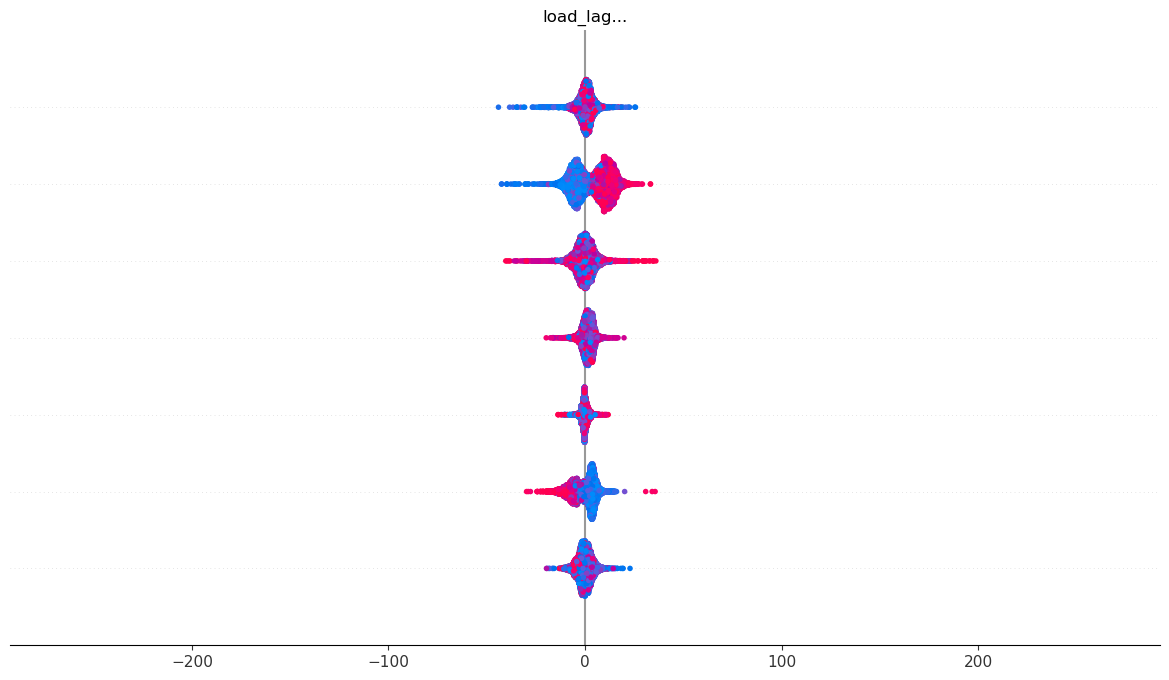

In [222]:
interaction_values = explainer.shap_interaction_values(X)
shap.summary_plot(interaction_values, X)

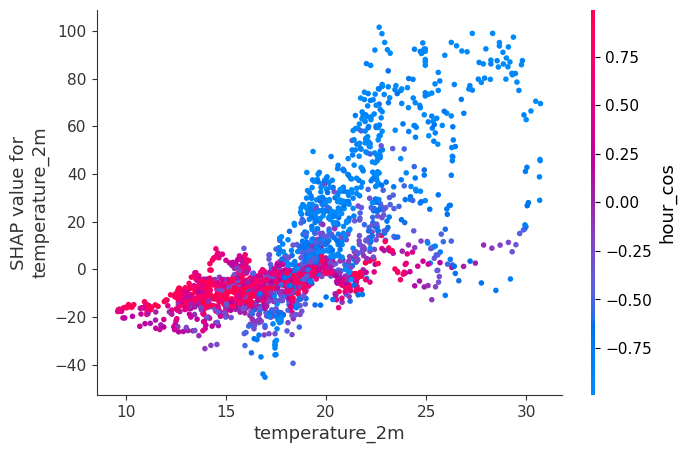

In [ ]:
explainer = shap.TreeExplainer(model)
shap_values = sh.shap_values(X_test)
shap.dependence_plot("temperature_2m", shap_values, X_test)

In [210]:
X100 = shap.utils.sample(X, 100)

In [ ]:
shap.dependence_plot("mean radius", shap_values, df_test[features])


# Notes on seasonal features
fourier = FourierFeaturizer(period_seconds=7*24*3600, order=4)
- dt : pd.Series (datetime64[ns], tz-aware or naive)
- period_seconds : float         Length of the seasonality in SECONDS (e.g., daily=86400, weekly=604800, yearly≈31557600).
- order : int         Number of Fourier terms (K). Produces 2*K columns (sin_k, cos_k).

where to use them in different industries
## Electricity demand (utility)
- hour_sin, hour_cos (K=1), dow_* dummies, doy_sin, doy_cos (K=1)
- Regressors: CDD/HDD, temp, humidity, lag_1h, lag_24h, lag_168h, holiday flag
- If morning/evening shoulders are complex → add daily Fourier K=2–4

## Retail demand (consumer)
- dow_* dummies, either month dummies or doy_sin, doy_cos
- Regressors: promo_type, promo_depth, price, ad_spend, stockout, holiday window flags
- Hourly data? add hour_sin, hour_cos (K=1)

## auto sales/parts
- month dummies, dow_*, doy_sin, doy_cos
- Regressors: incentive_$, model_launch, inventory_days, gas_price, interest_rate, weather shocks
- For aftersales/service: add snow/rain and event flags (storms)

## Ridesharing
- hour_sin, hour_cos (K=2), dow_*, doy_sin, doy_cos
- Regressors: rain, temp, event_nearby, surge_index, transit_outage
- Consider city embeddings if multi-city model

## Hospitality
- doy_sin, doy_cos (K=1–2), month dummies, dow_*
- Regressors: event_calendar, school_break, airfare_index, lead_time, min_stay
- Add arrival_day_before_event counters for big conferences


Linear models: Use either DOW dummies or is_weekend (not both).

In [ ]:

If your monthly pattern has sharp, non-sinusoidal bumps (e.g., holiday sales), sin/cos can underfit.
Less direct interpretability per-month.